In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 12})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_01/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [3]:
#### Setting path to results directory

load_dir = "../system_01/results/lyapunov_numba/"
load_str = datetime.datetime(2025, 1, 14)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

params['dt'] = 0.005 #x10ms

Total no. of files = 10


In [4]:
### Setting the parameters
iE = 0.25 / params['gamma'] - params['i_e2']
kMin = -1; kMax = 1; kSteps = 20
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 16.5; sSteps = 25
sVals = sMin + np.arange(0, sSteps) / (sSteps - 1) * (sMax - sMin)

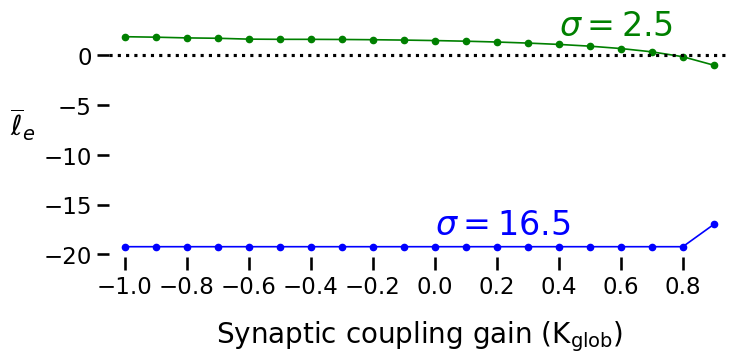

In [5]:
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}_dt_{params['dt']}" not in path_:
        continue

    lyap_results = pickle.load(open(path_, 'rb'))
    lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results

    ## Adjusting for -inf values
    minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue
    
    lowHetLyap = lyap_results[:, 0]
    HighHetLyap = lyap_results[:, -1]

    plt.figure(figsize=(8, 3))
    plt.plot(kVals, lowHetLyap, 'g.-', linewidth=1.2); plt.text(0.4, 2, r"$\sigma=$2.5", color='g', fontsize=24)
    plt.plot(kVals, HighHetLyap, 'b.-', linewidth=1.2); plt.text(0.0, -18, r"$\sigma=$"+f"{sVals[-1]:.1f}", color='b', fontsize=24)
    plt.axhline(y=0, color = 'k', linestyle=':')
    plt.ylabel(r"$\overline{\ell}_e$", fontsize=20, rotation=0, labelpad=15)
    plt.xlabel(r"Synaptic coupling gain $(\rm K_{glob})$", fontsize=20, labelpad=15)
    plt.xlim(kMin-0.05, max(kVals)+0.05)
    plt.xticks(kVals[::2])

    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)
        
    plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_dt_{params.get('dt')*10}ms.png"), dpi=300, bbox_inches='tight')
        

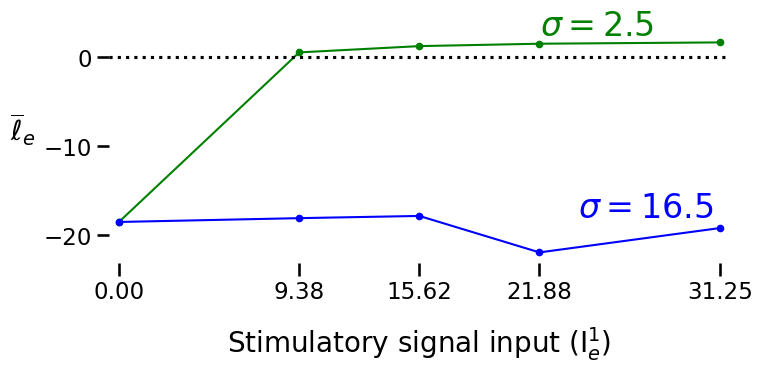

In [6]:
lowHetLyap = {}
HighHetLyap = {}

Kind = 3
for path_ in file_paths:    
    Basename = os.path.basename(path_).split('.pkl')[0]
    iE = float(Basename.split('_ie_')[-1].split('_dt_')[0]) - params['i_e2']

    lyap_results = pickle.load(open(path_, 'rb'))
    lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results

    minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue

    lowHetLyap[iE] = lyap_results[Kind, 0]
    HighHetLyap[iE] = lyap_results[Kind, -1]

iEvals = np.array(list(lowHetLyap.keys()))
iEsort = np.argsort(iEvals)
lowLyap = np.array(list(lowHetLyap.values()))
highLyap = np.array(list(HighHetLyap.values()))

lowLyap = lowLyap[iEsort]
highLyap = highLyap[iEsort]
iEvals = iEvals[iEsort]

plt.figure(figsize=(8, 3))
plt.plot(iEvals, lowLyap, 'g.-', linewidth=1.5); plt.text(21.88, 2.5, r"$\sigma=$2.5", color='g', fontsize=24)
plt.plot(iEvals, highLyap, 'b.-', linewidth=1.5); plt.text(23.88, -18, r"$\sigma=$16.5", color='b', fontsize=24)
plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_e$", fontsize=20, rotation=0, labelpad=15)
plt.xlabel(r"Stimulatory signal input $(\mathrm{I}^1_e)$", fontsize=20, labelpad=15)
plt.xticks(iEvals)
plt.xlim(min(iEvals)-0.5, max(iEvals)+0.5)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_Imod_dt_{params.get('dt')*10}ms.png"), dpi=300, bbox_inches='tight')

#### State transition boundary detection

In [7]:
# setting the variables
kMin = -1; kMax = 1; kSteps = 20
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 16.5; sSteps = 25
sVals = sMin + np.arange(0, sSteps) / (sSteps - 1) * (sMax - sMin)

In [11]:
### Loading files to create the heatmaps with F(u) values.
save_str = datetime.datetime(2025, 1, 18)
params['dt'] = 0.005
results_dict = os.path.join('../system_01/results/Fu_numba/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths_mean = glob.glob(os.path.join(results_dict, f"*_dt_{params['dt']}msmean.pkl"))
file_paths_var = glob.glob(os.path.join(results_dict, f"*_dt_{params['dt']}msvar.pkl"))
num_files = len(file_paths_mean)
print(f"Number of files: {num_files}")

Number of files: 5


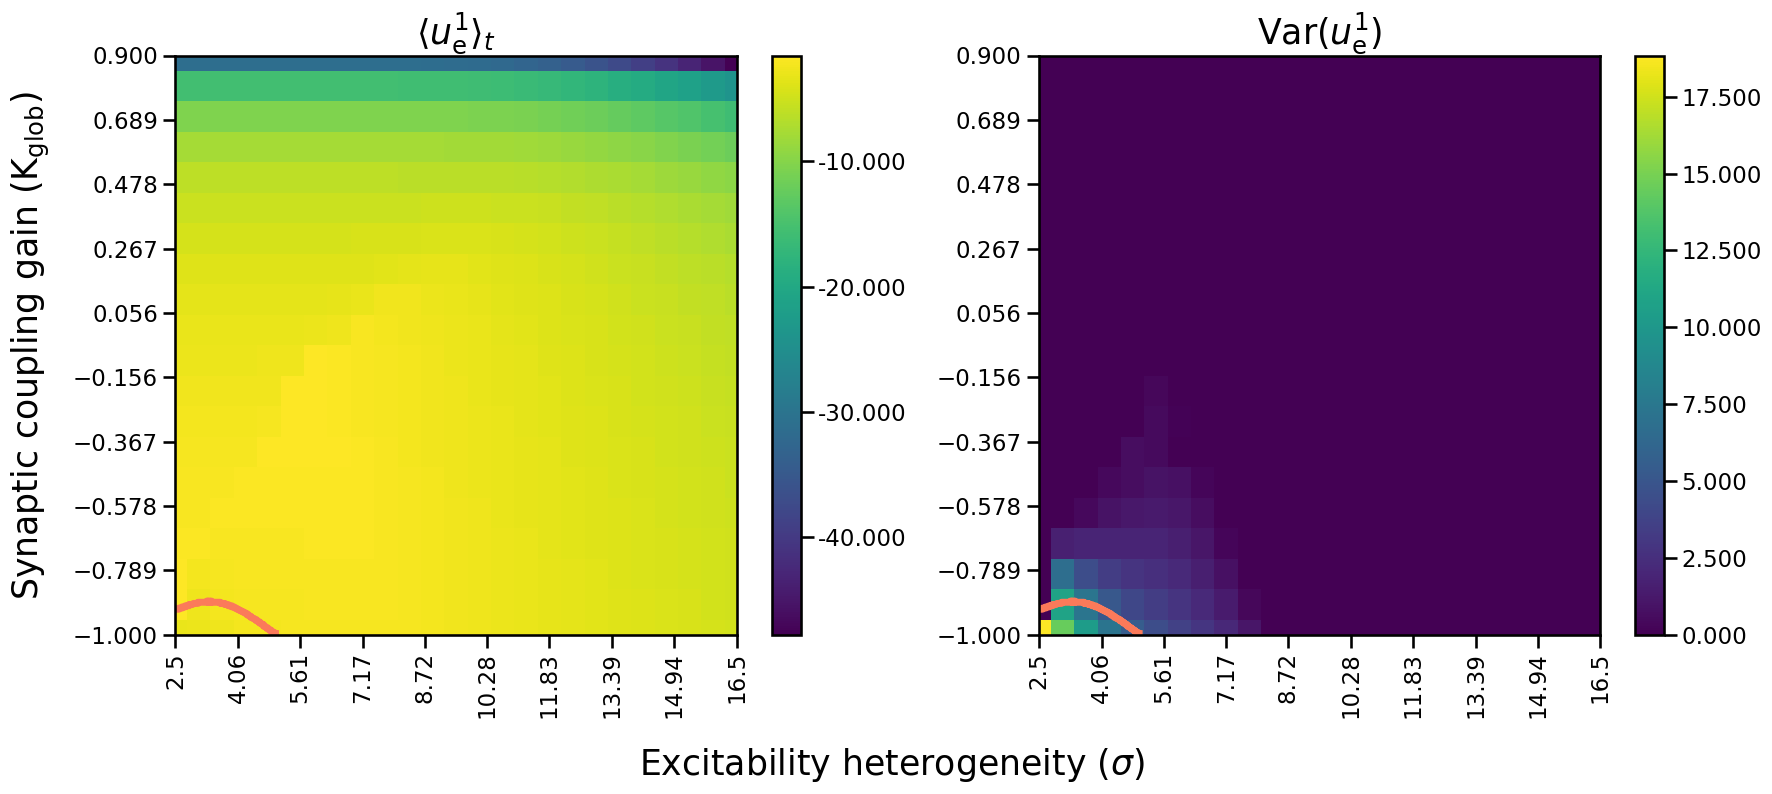

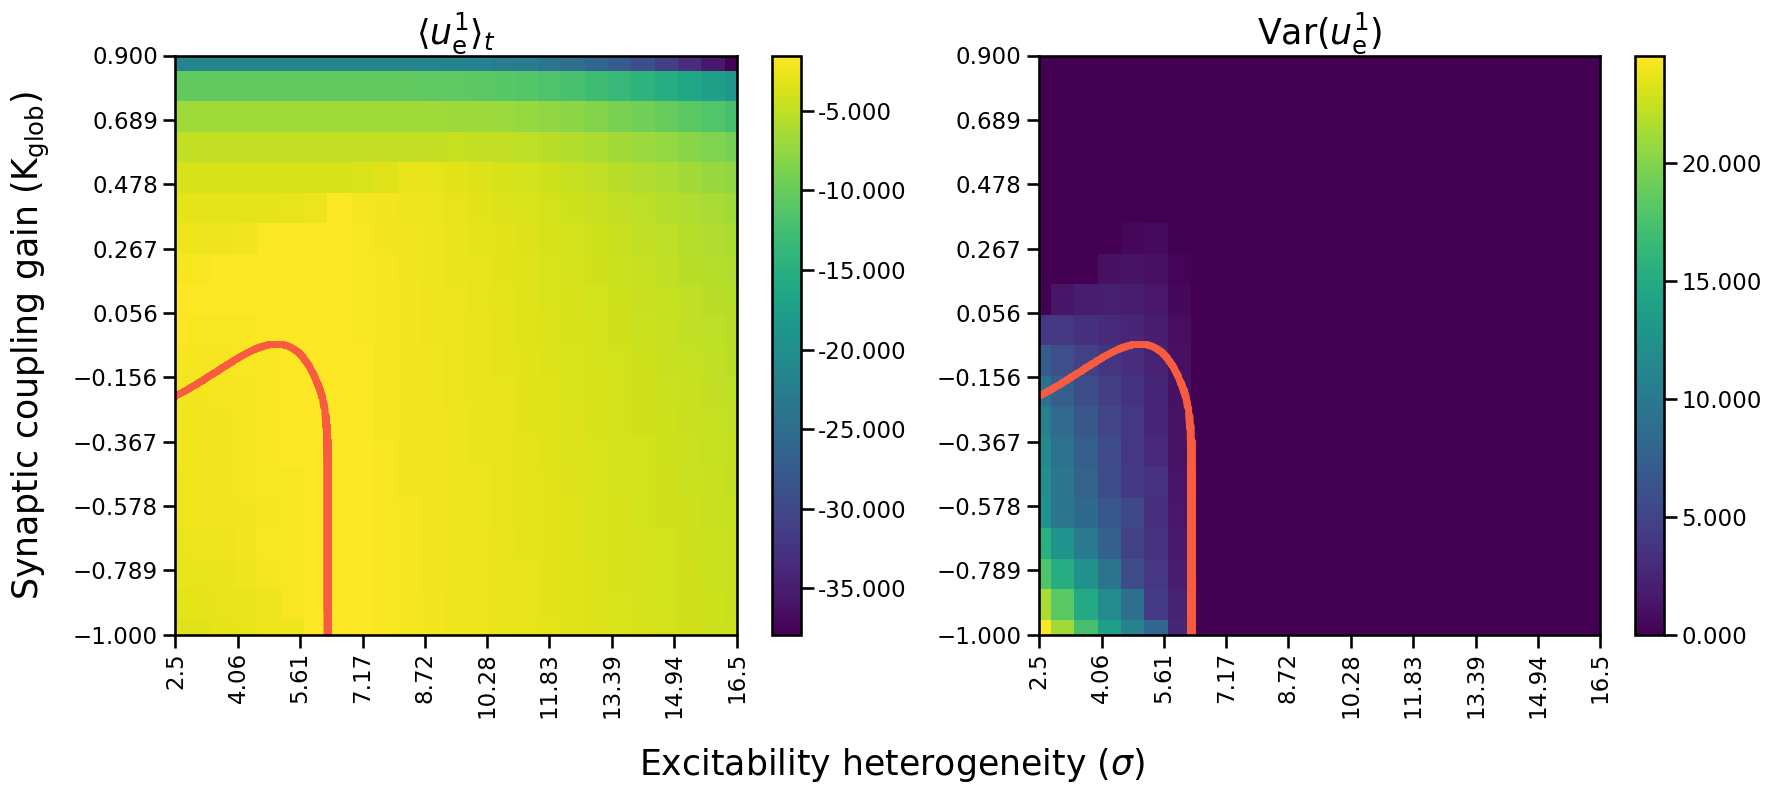

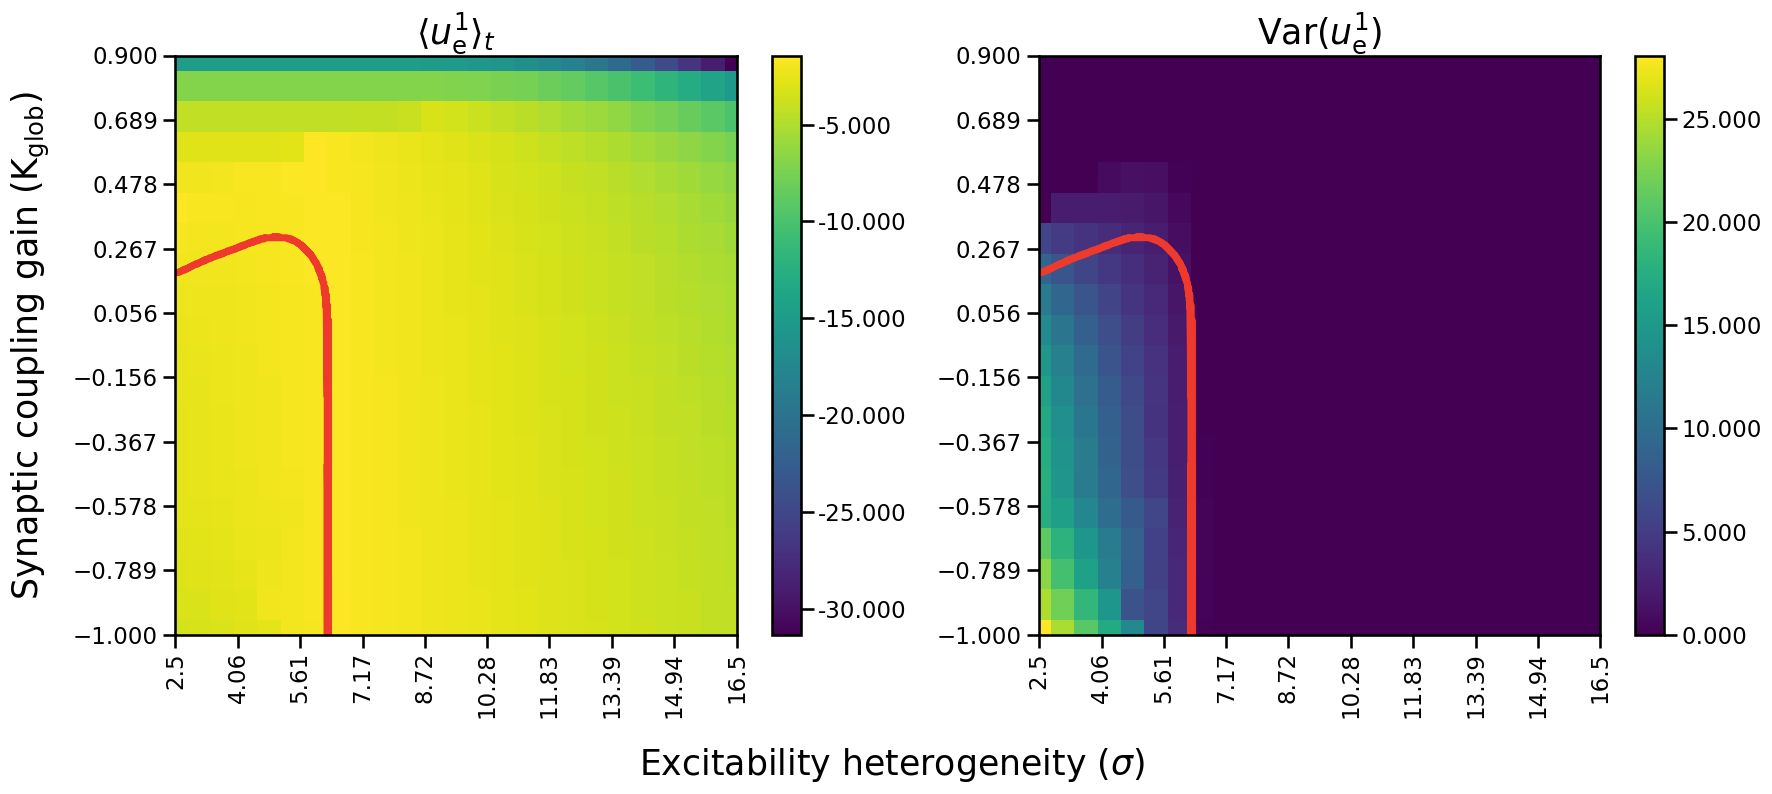

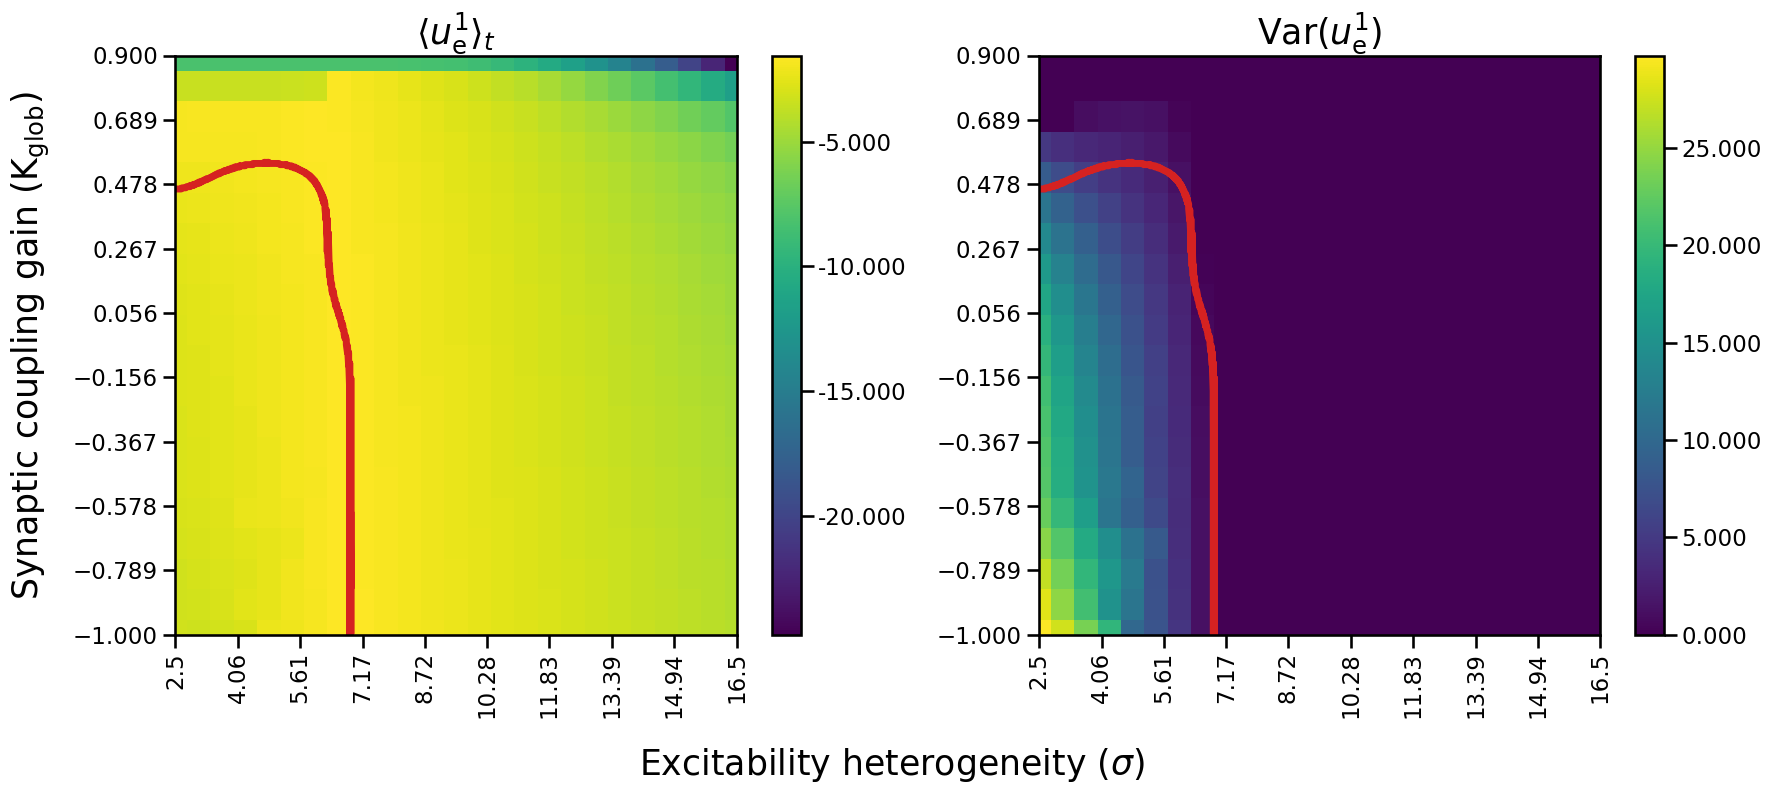

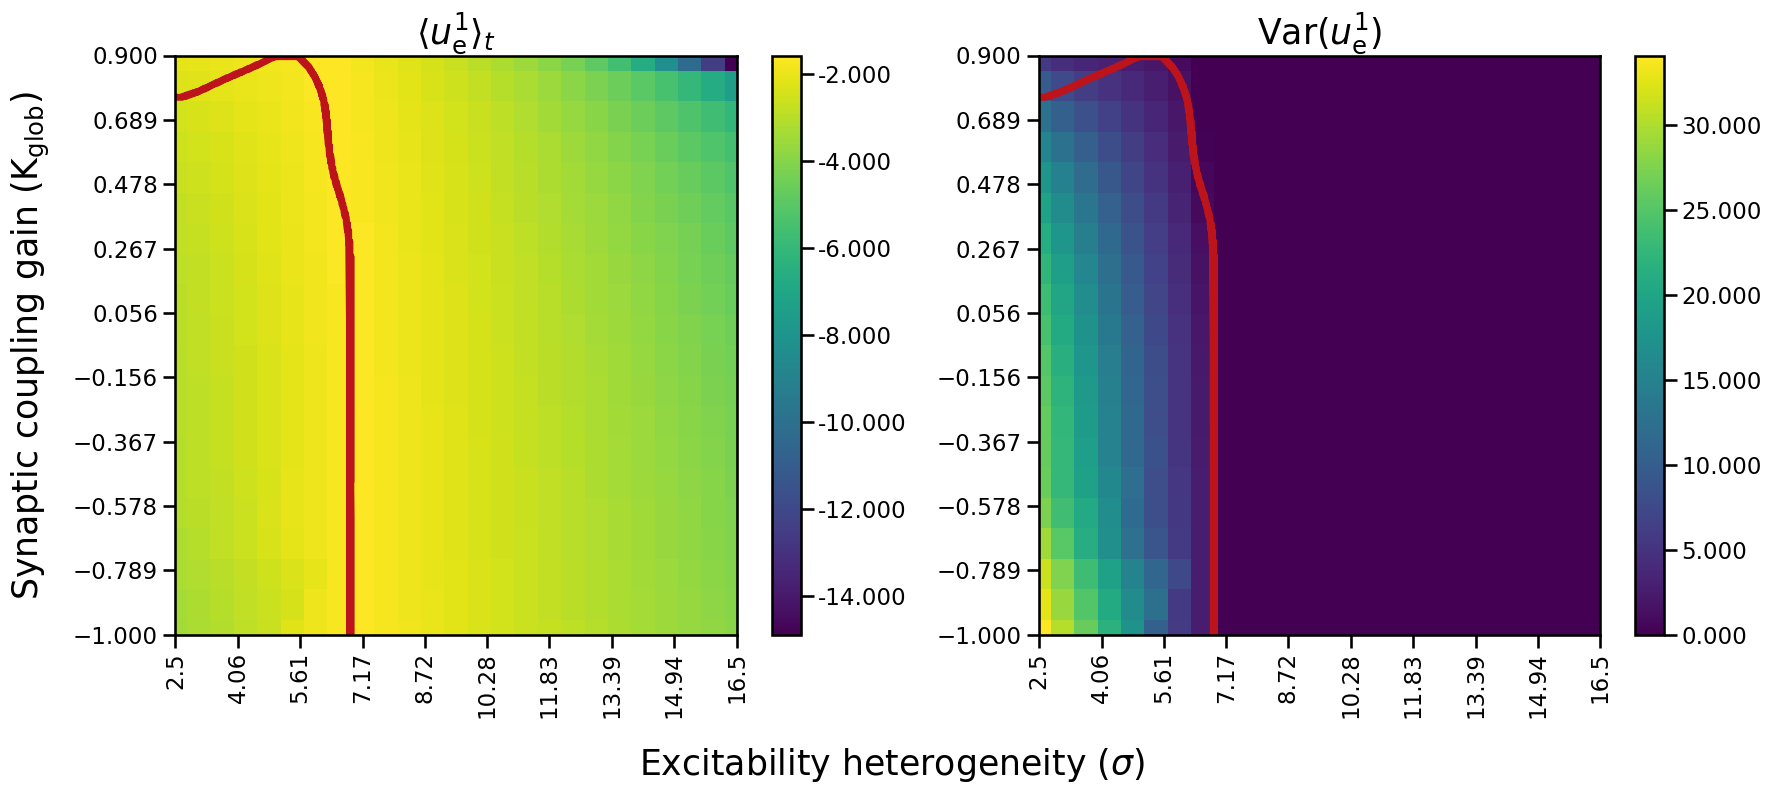

In [21]:
_I = []

for nf, path in enumerate(file_paths_mean):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths_mean = np.array(file_paths_mean)[_Isort]

_I = []

for nf, path in enumerate(file_paths_var):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths_var = np.array(file_paths_var)[_Isort]

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.45, 0.8, len(_I))))
subtitles = [r"$\langle u_{\rm e}^1 \rangle_t$", r"$\mathrm{Var}(u_{\rm e}^1)$"]


for nf, (path_mean, path_var) in enumerate(zip(file_paths_mean, file_paths_var)):
    basename = os.path.basename(path_mean).split('.pkl')[0]
    color = next(colorIter)
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])

    ## Reading the Lyapunov exponent file corresponding to eah I value

    lyap_results_boundary = pickle.load(open(f"../system_01/results/lyapunov_numba/exp-2025-1-14/lyap_ie_{I:.3f}_dt_{params['dt']}ms.pkl", 'rb'))
    lyap_results_boundary = lyap_results_boundary['n1_mean'] if type(lyap_results_boundary) == dict else lyap_results_boundary

    orig_response = lyapunov_threshold(lyap_results_boundary, 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response=orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )

    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)


    ## Reading the mean and var value file
    mean_results = pickle.load(open(path_mean, 'rb'))
    var_results = pickle.load(open(path_var, 'rb'))
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,8))
    for i in range(4):
        if i != 0:
            continue
        heatmap_1 = axes[0].pcolormesh(sVals, kVals, mean_results[i, :, :])
        cbar_1 = plt.colorbar(heatmap_1, format='%.3f')

        heatmap_2 = axes[1].pcolormesh(sVals, kVals, var_results[i, :, :])
        cbar_2 = plt.colorbar(heatmap_2, format='%.3f')


    for nRow in range(2):
        axes[nRow].plot(sig_edges, k_edges, linewidth=5, c = color)

        axes[nRow].set_xticks(np.round(np.linspace(sMin, max(sVals), 10), 2))
        axes[nRow].set_xticklabels(np.round(np.linspace(sMin, max(sVals), 10), 2), rotation = 90)
        axes[nRow].set_yticks(np.linspace(kMin, max(kVals), 10))
        axes[nRow].set_xlim(sMin, max(sVals)); axes[nRow].set_ylim(kMin, max(kVals))

        axes[nRow].set_title(subtitles[nRow], fontsize=25)
        if nRow == 0:
            axes[nRow].set_ylabel(r"Synaptic coupling gain $(\rm K_{glob})$", fontsize=25, labelpad=15)
        
    fig.supxlabel(r"Excitability heterogeneity $(\sigma)$", fontsize=25)
    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, f"Mean_ue1_Heatmaps_{params.get('dt')*10:.3f}ms_ie_{I:.3f}mV.jpg"), dpi = 300, bbox_inches='tight')
    plt.show()

In [8]:
### Loading files to create the heatmaps with F(u) values.
save_str = datetime.datetime(2025, 1, 17)
params['dt'] = 0.005
results_dict = os.path.join('../system_01/results/Fu_numba/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, f"*_dt_{params['dt']}ms.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 5


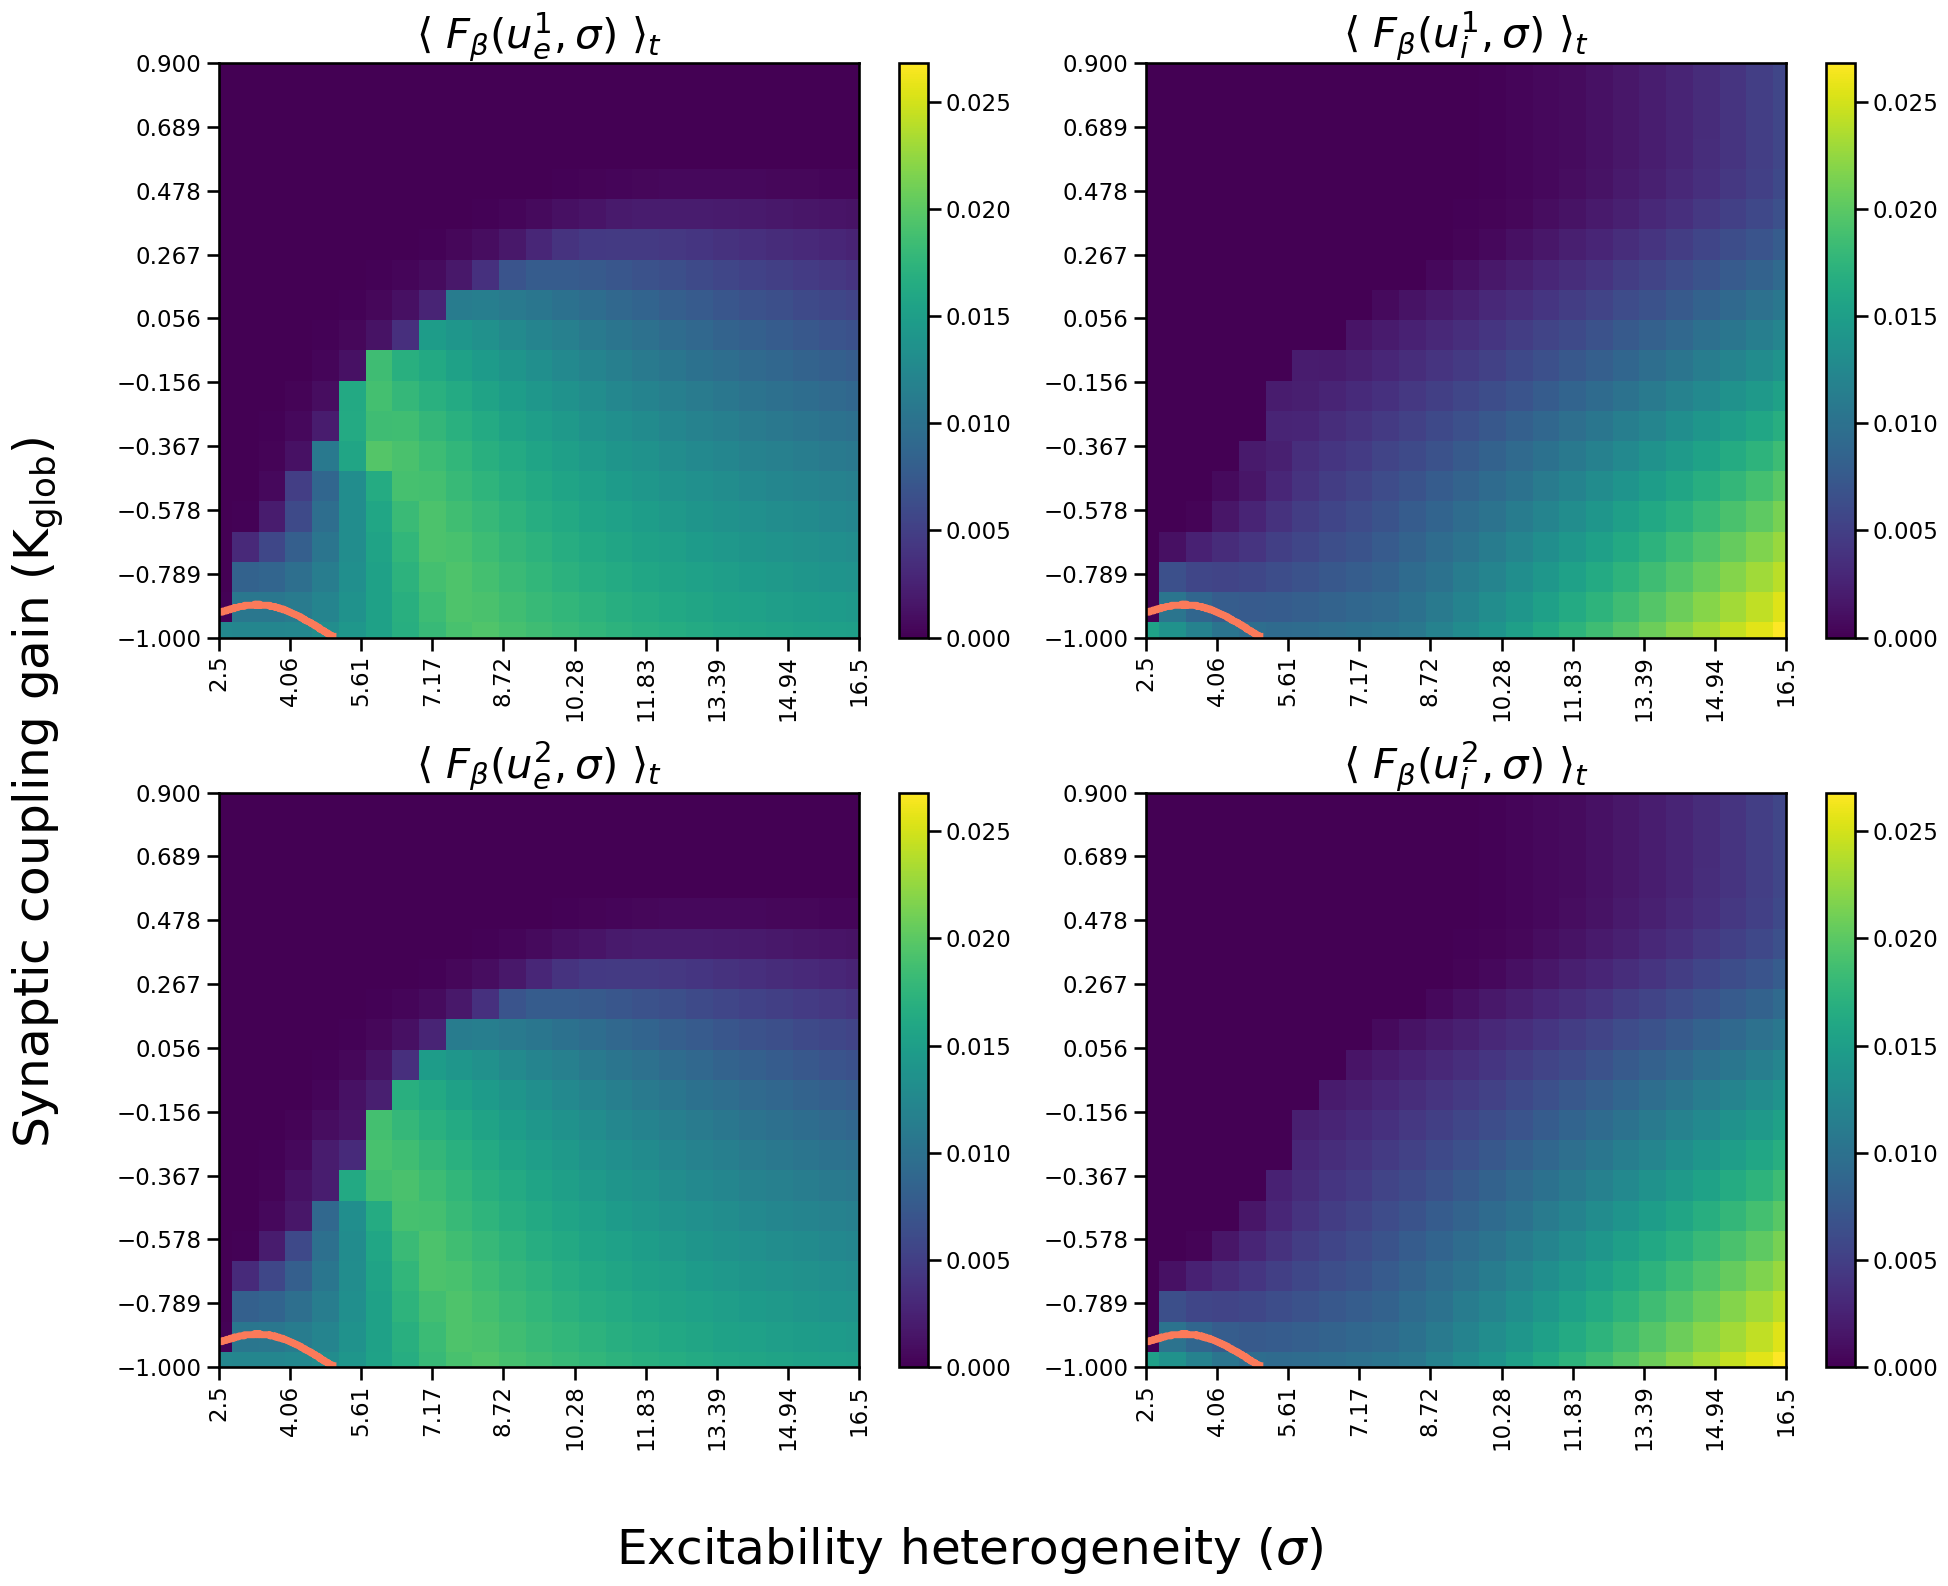

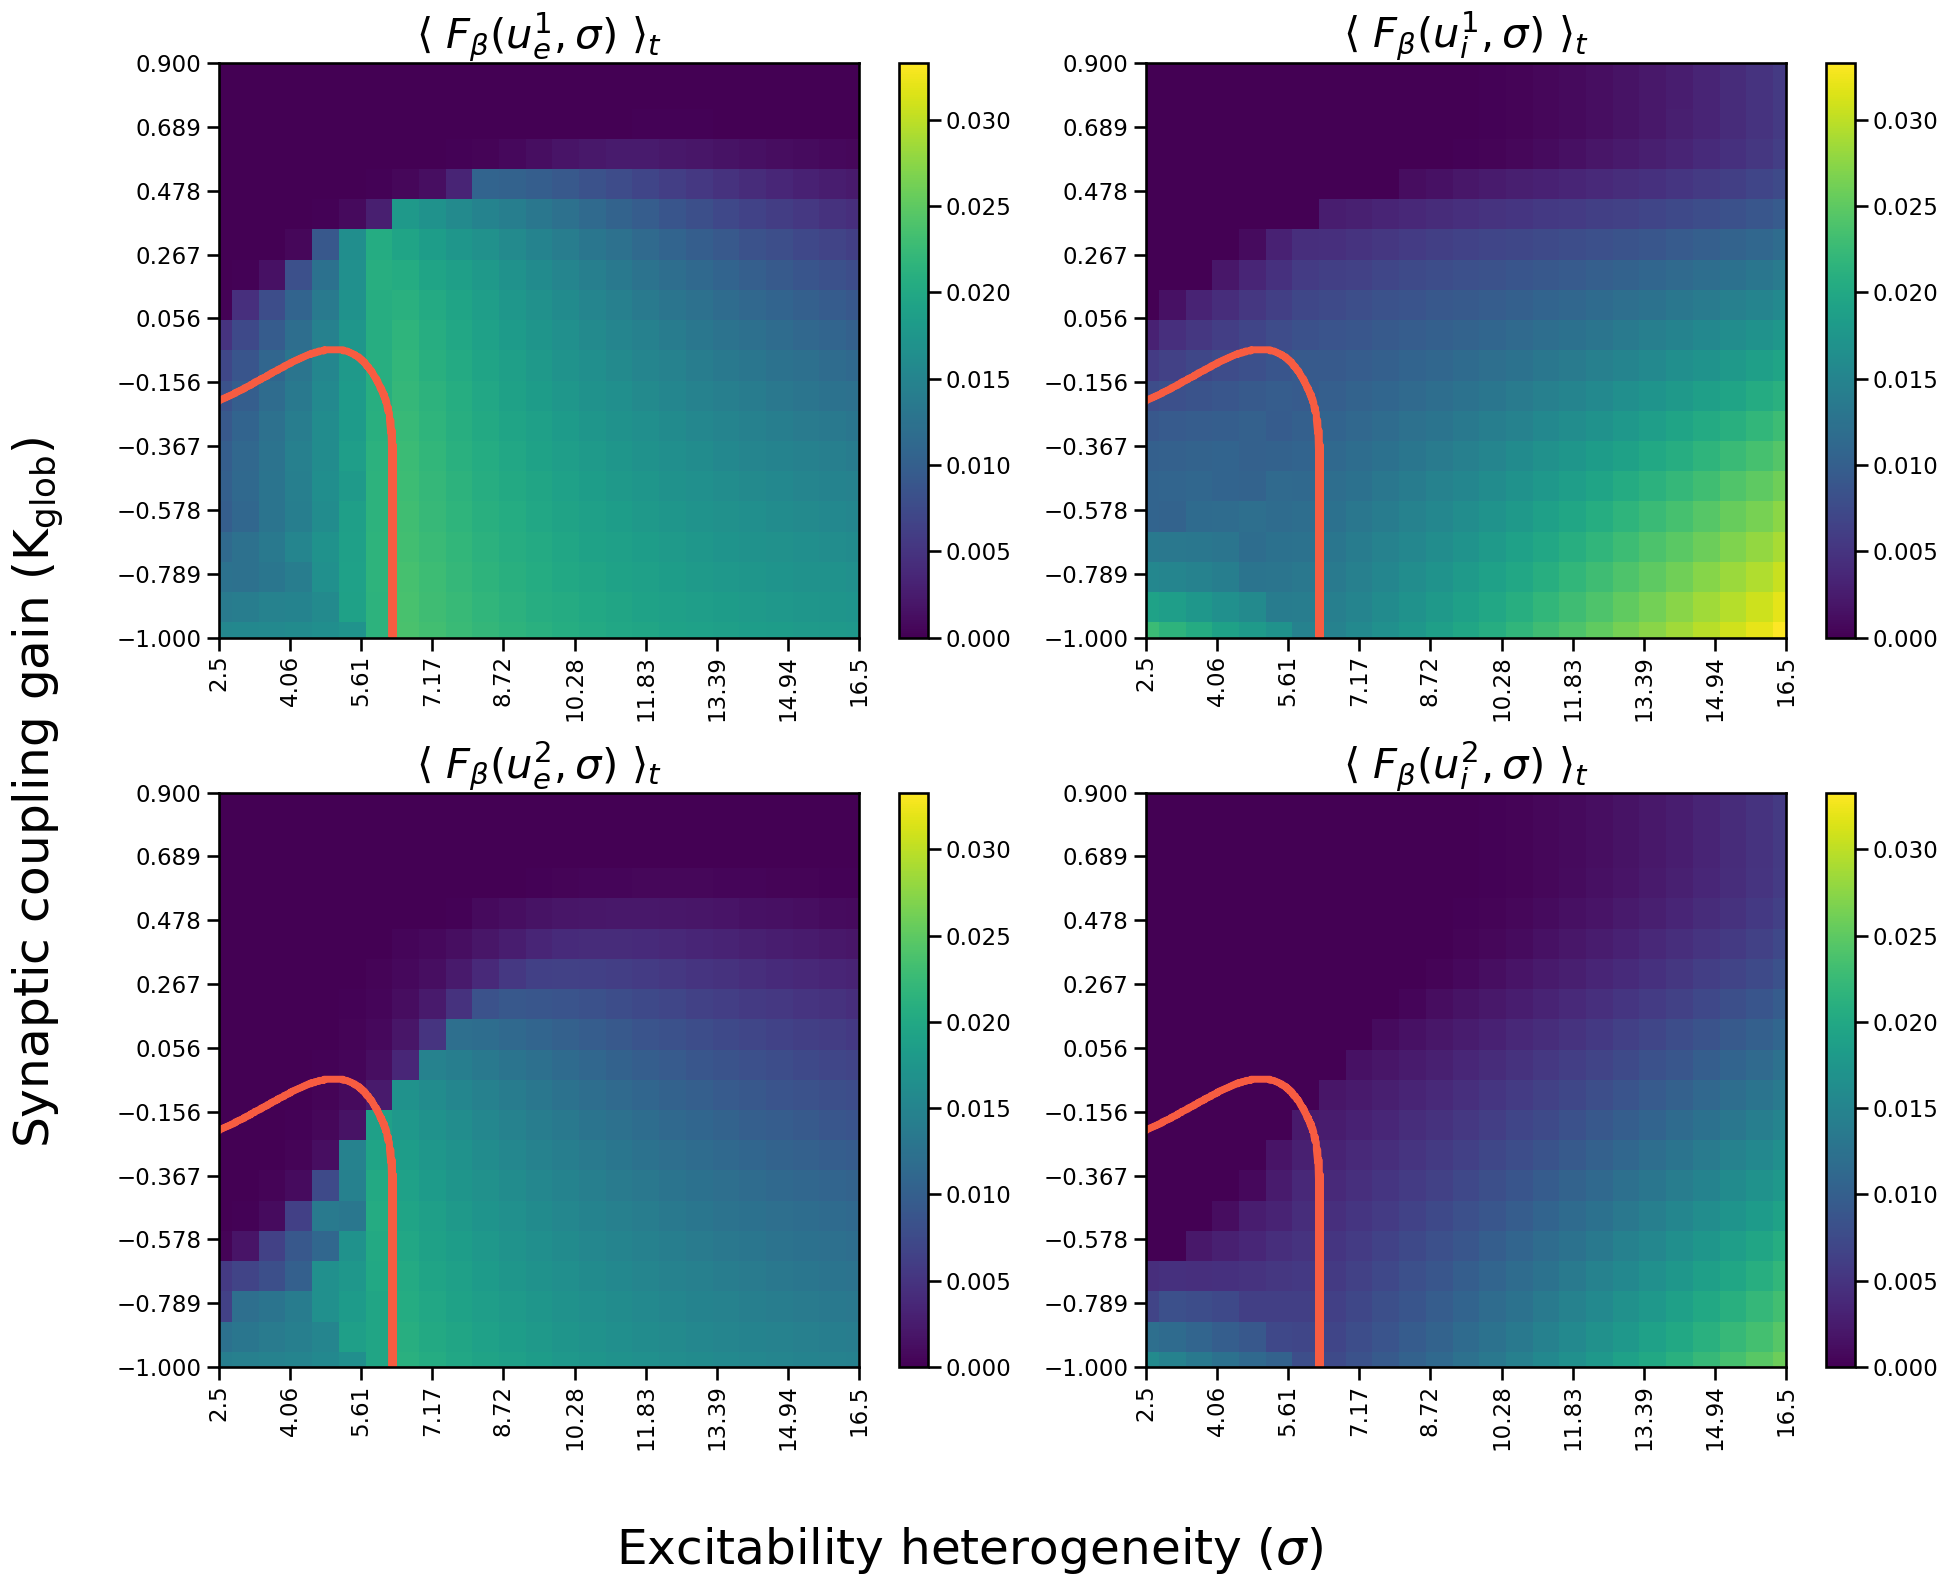

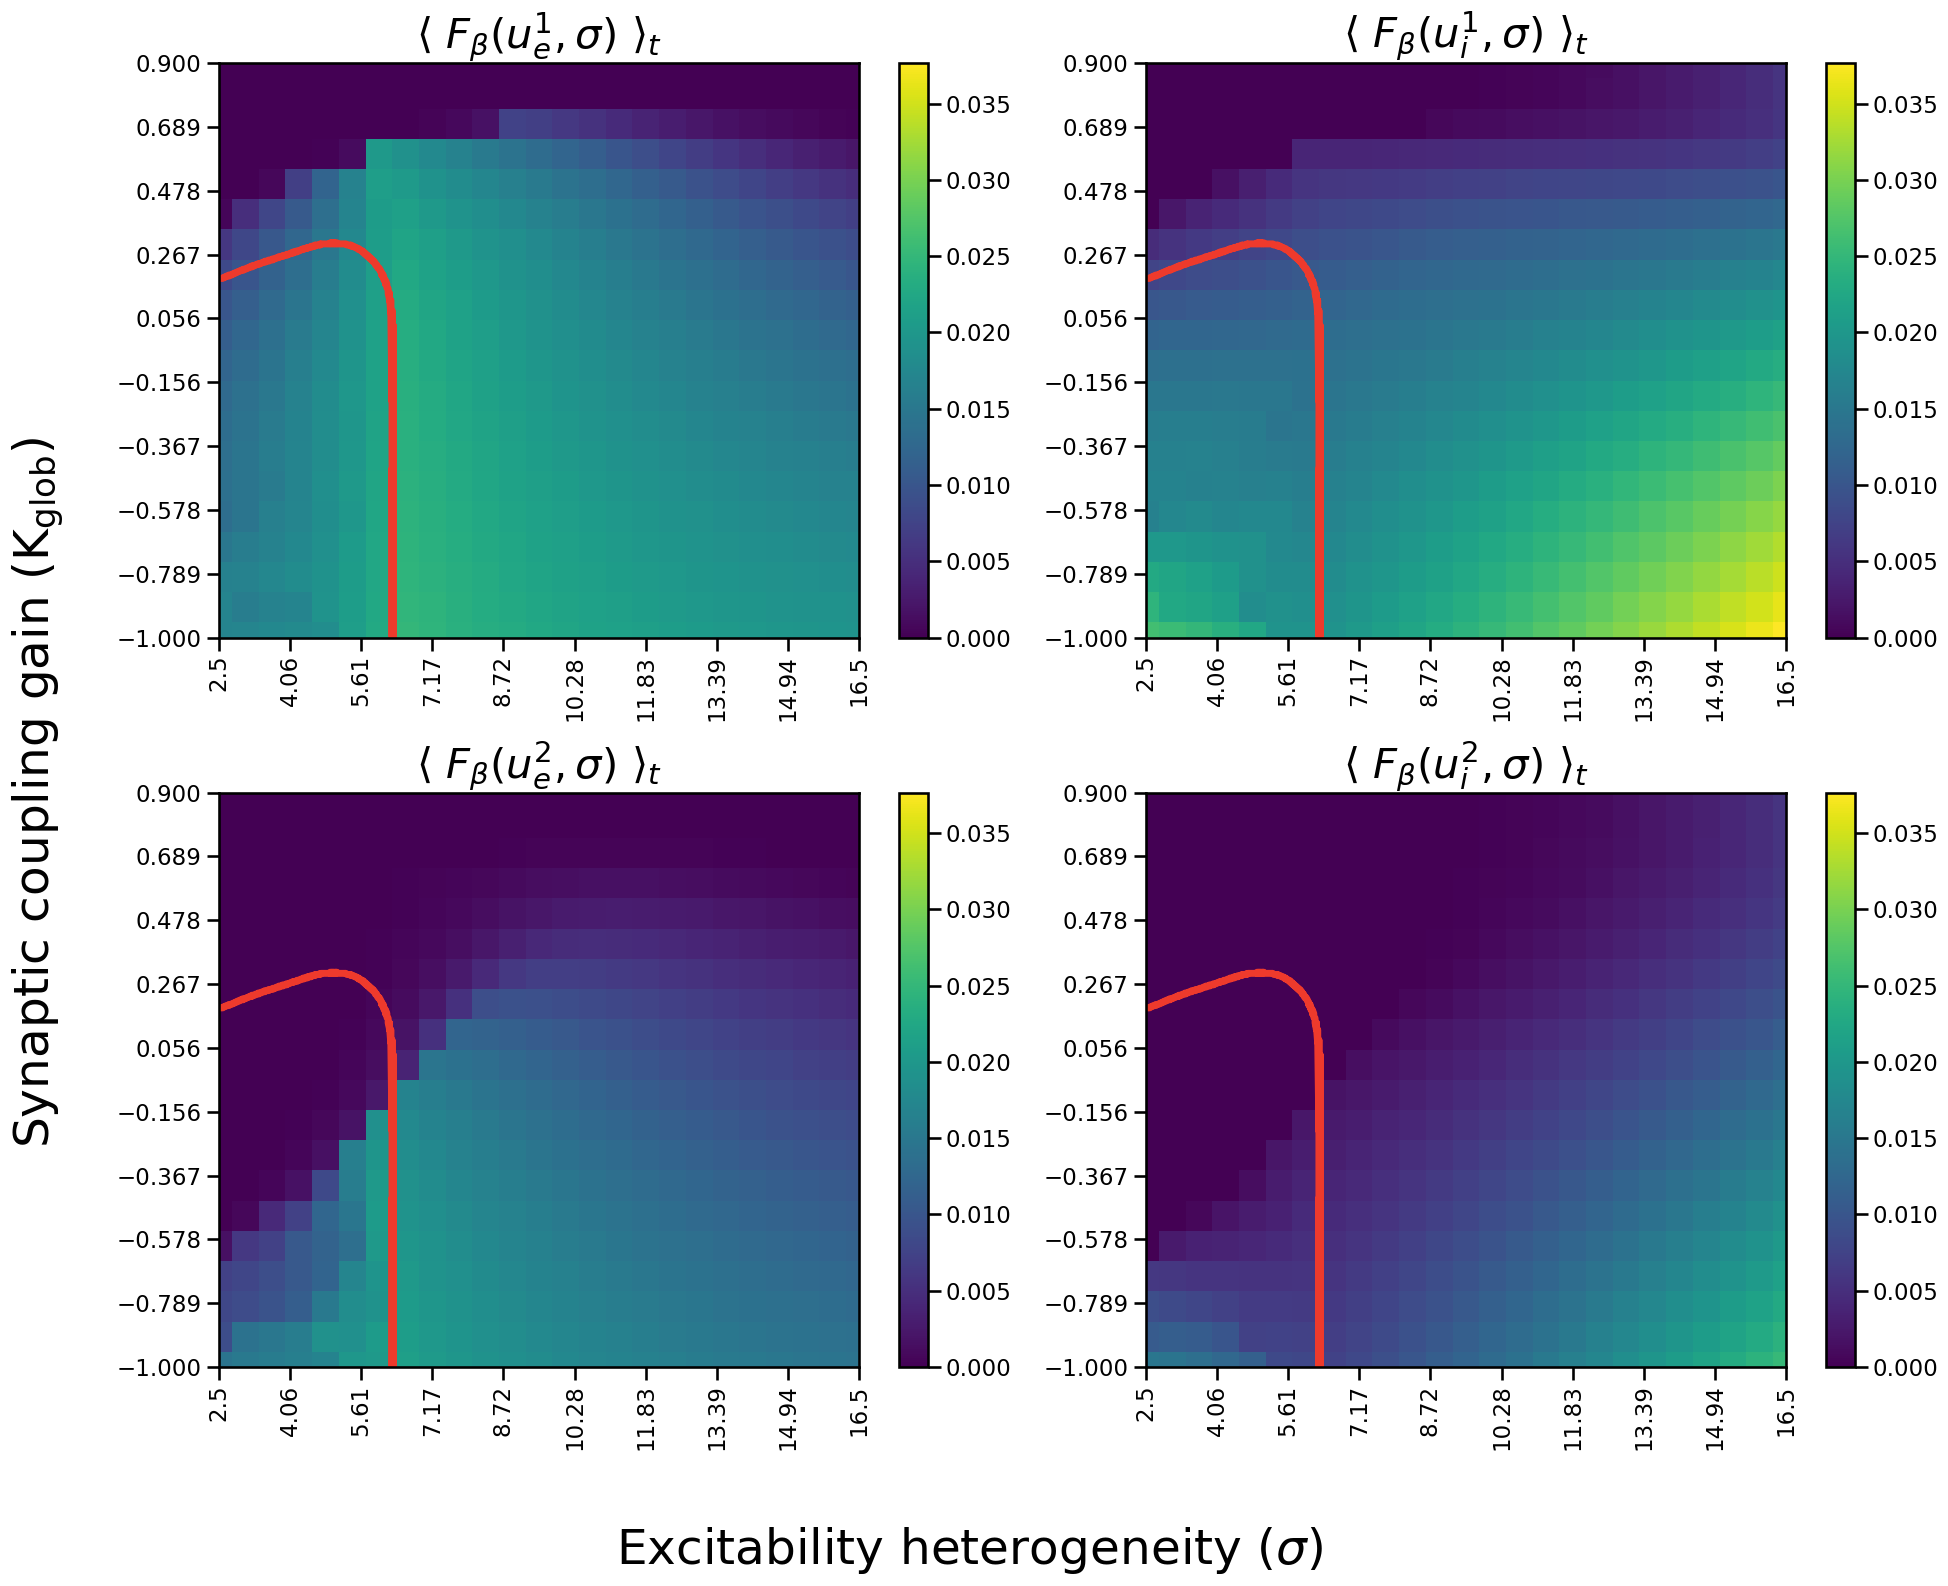

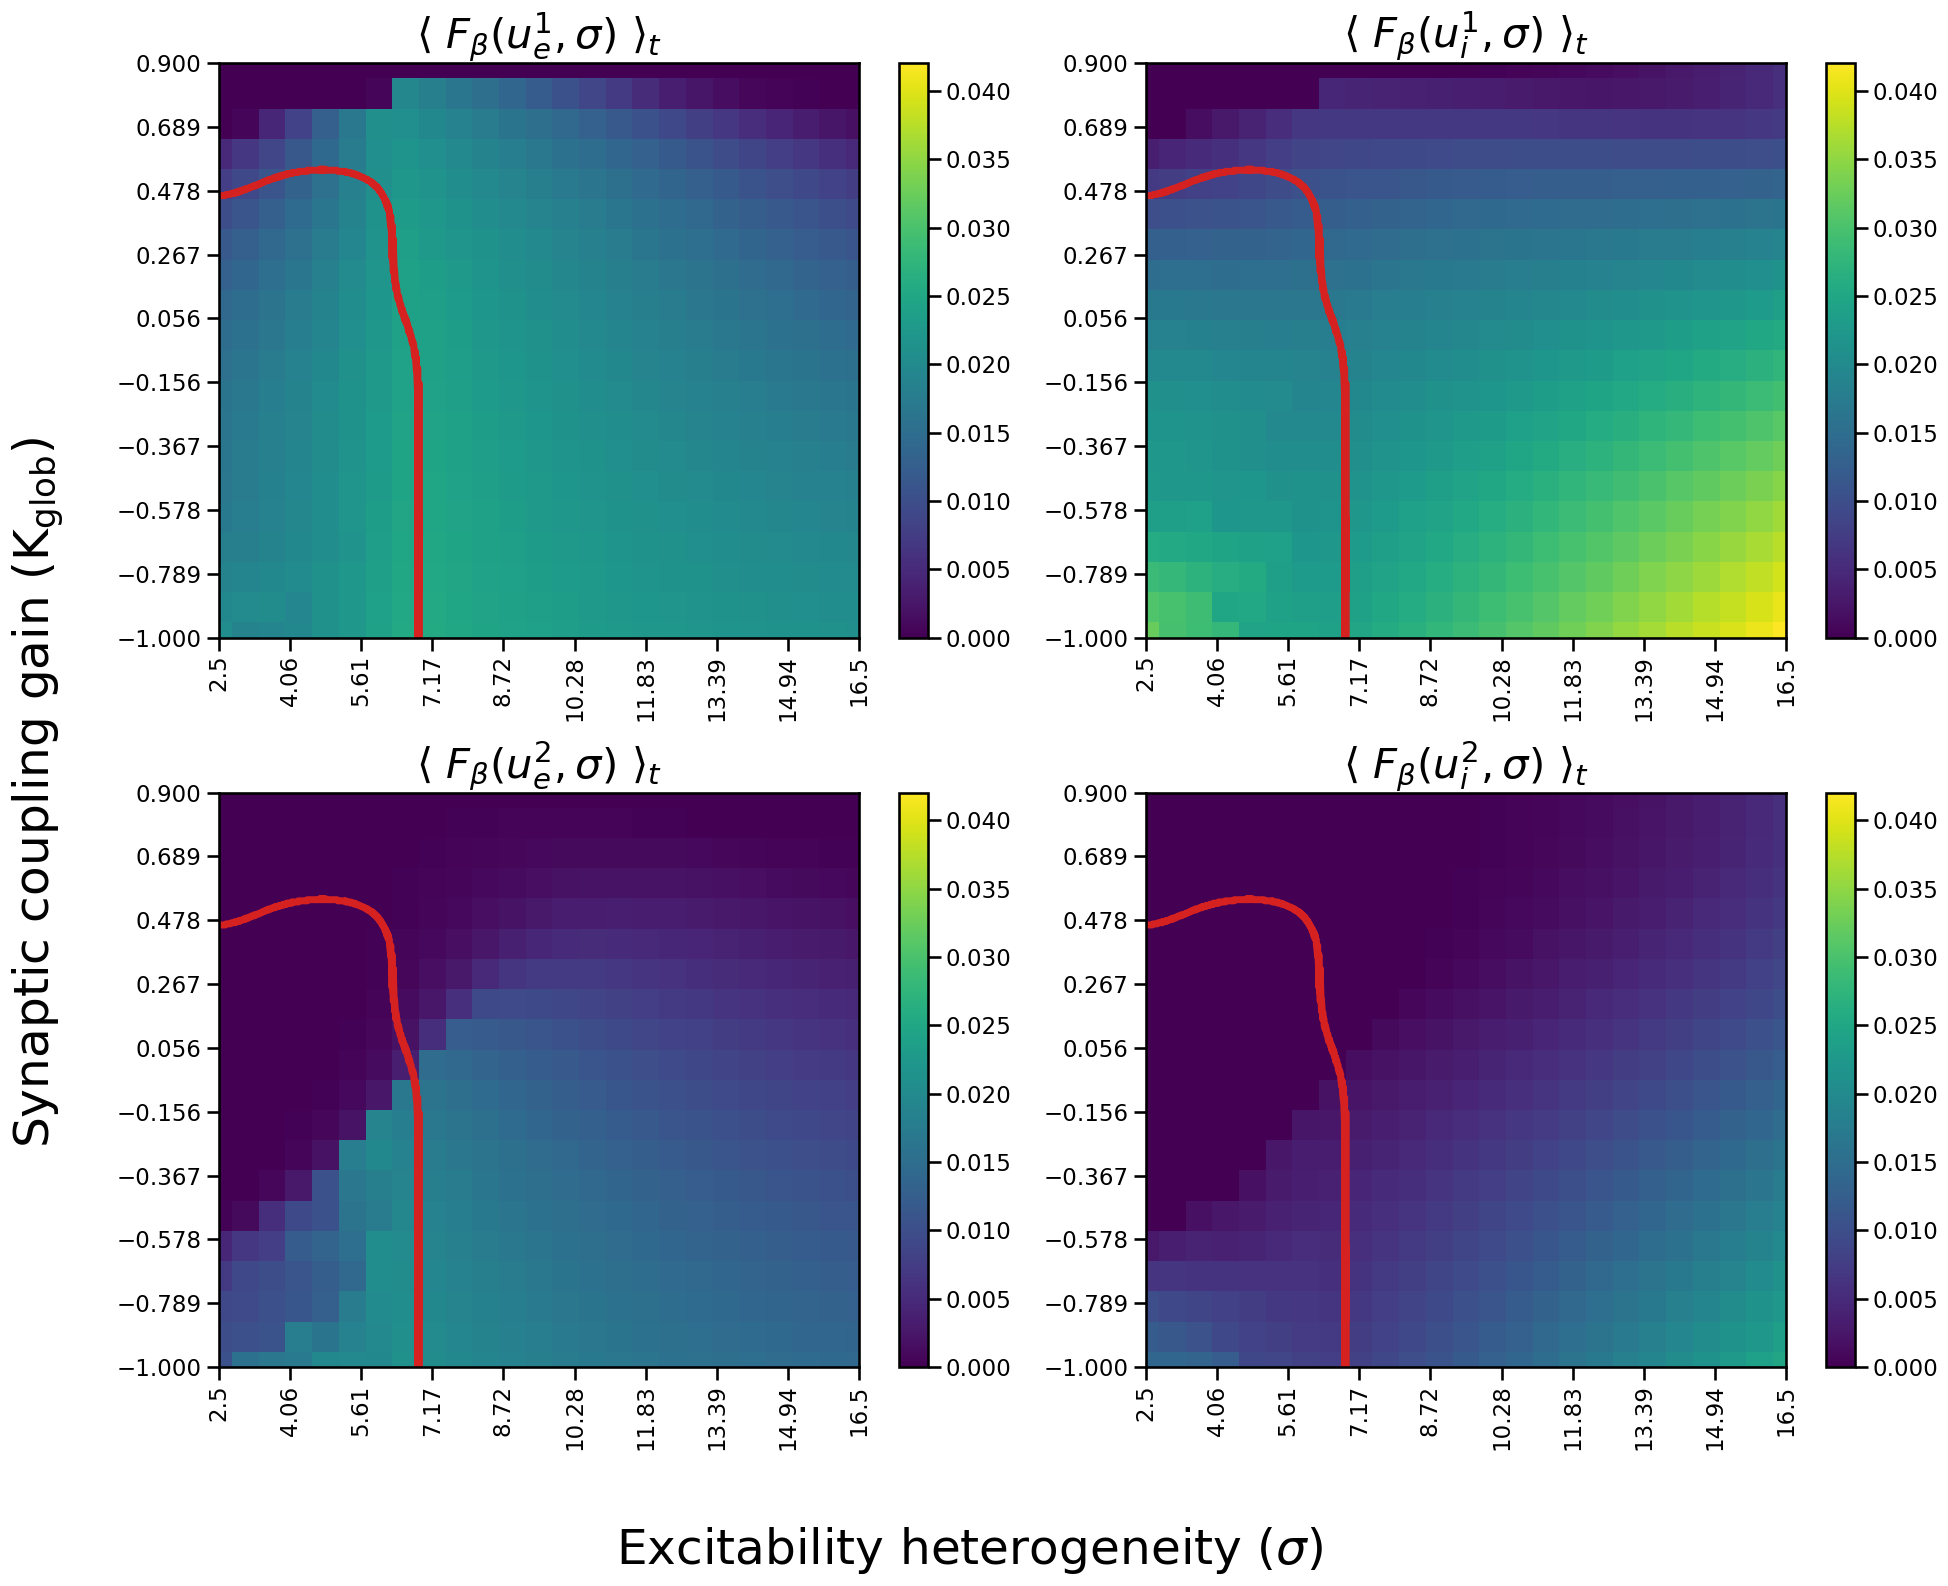

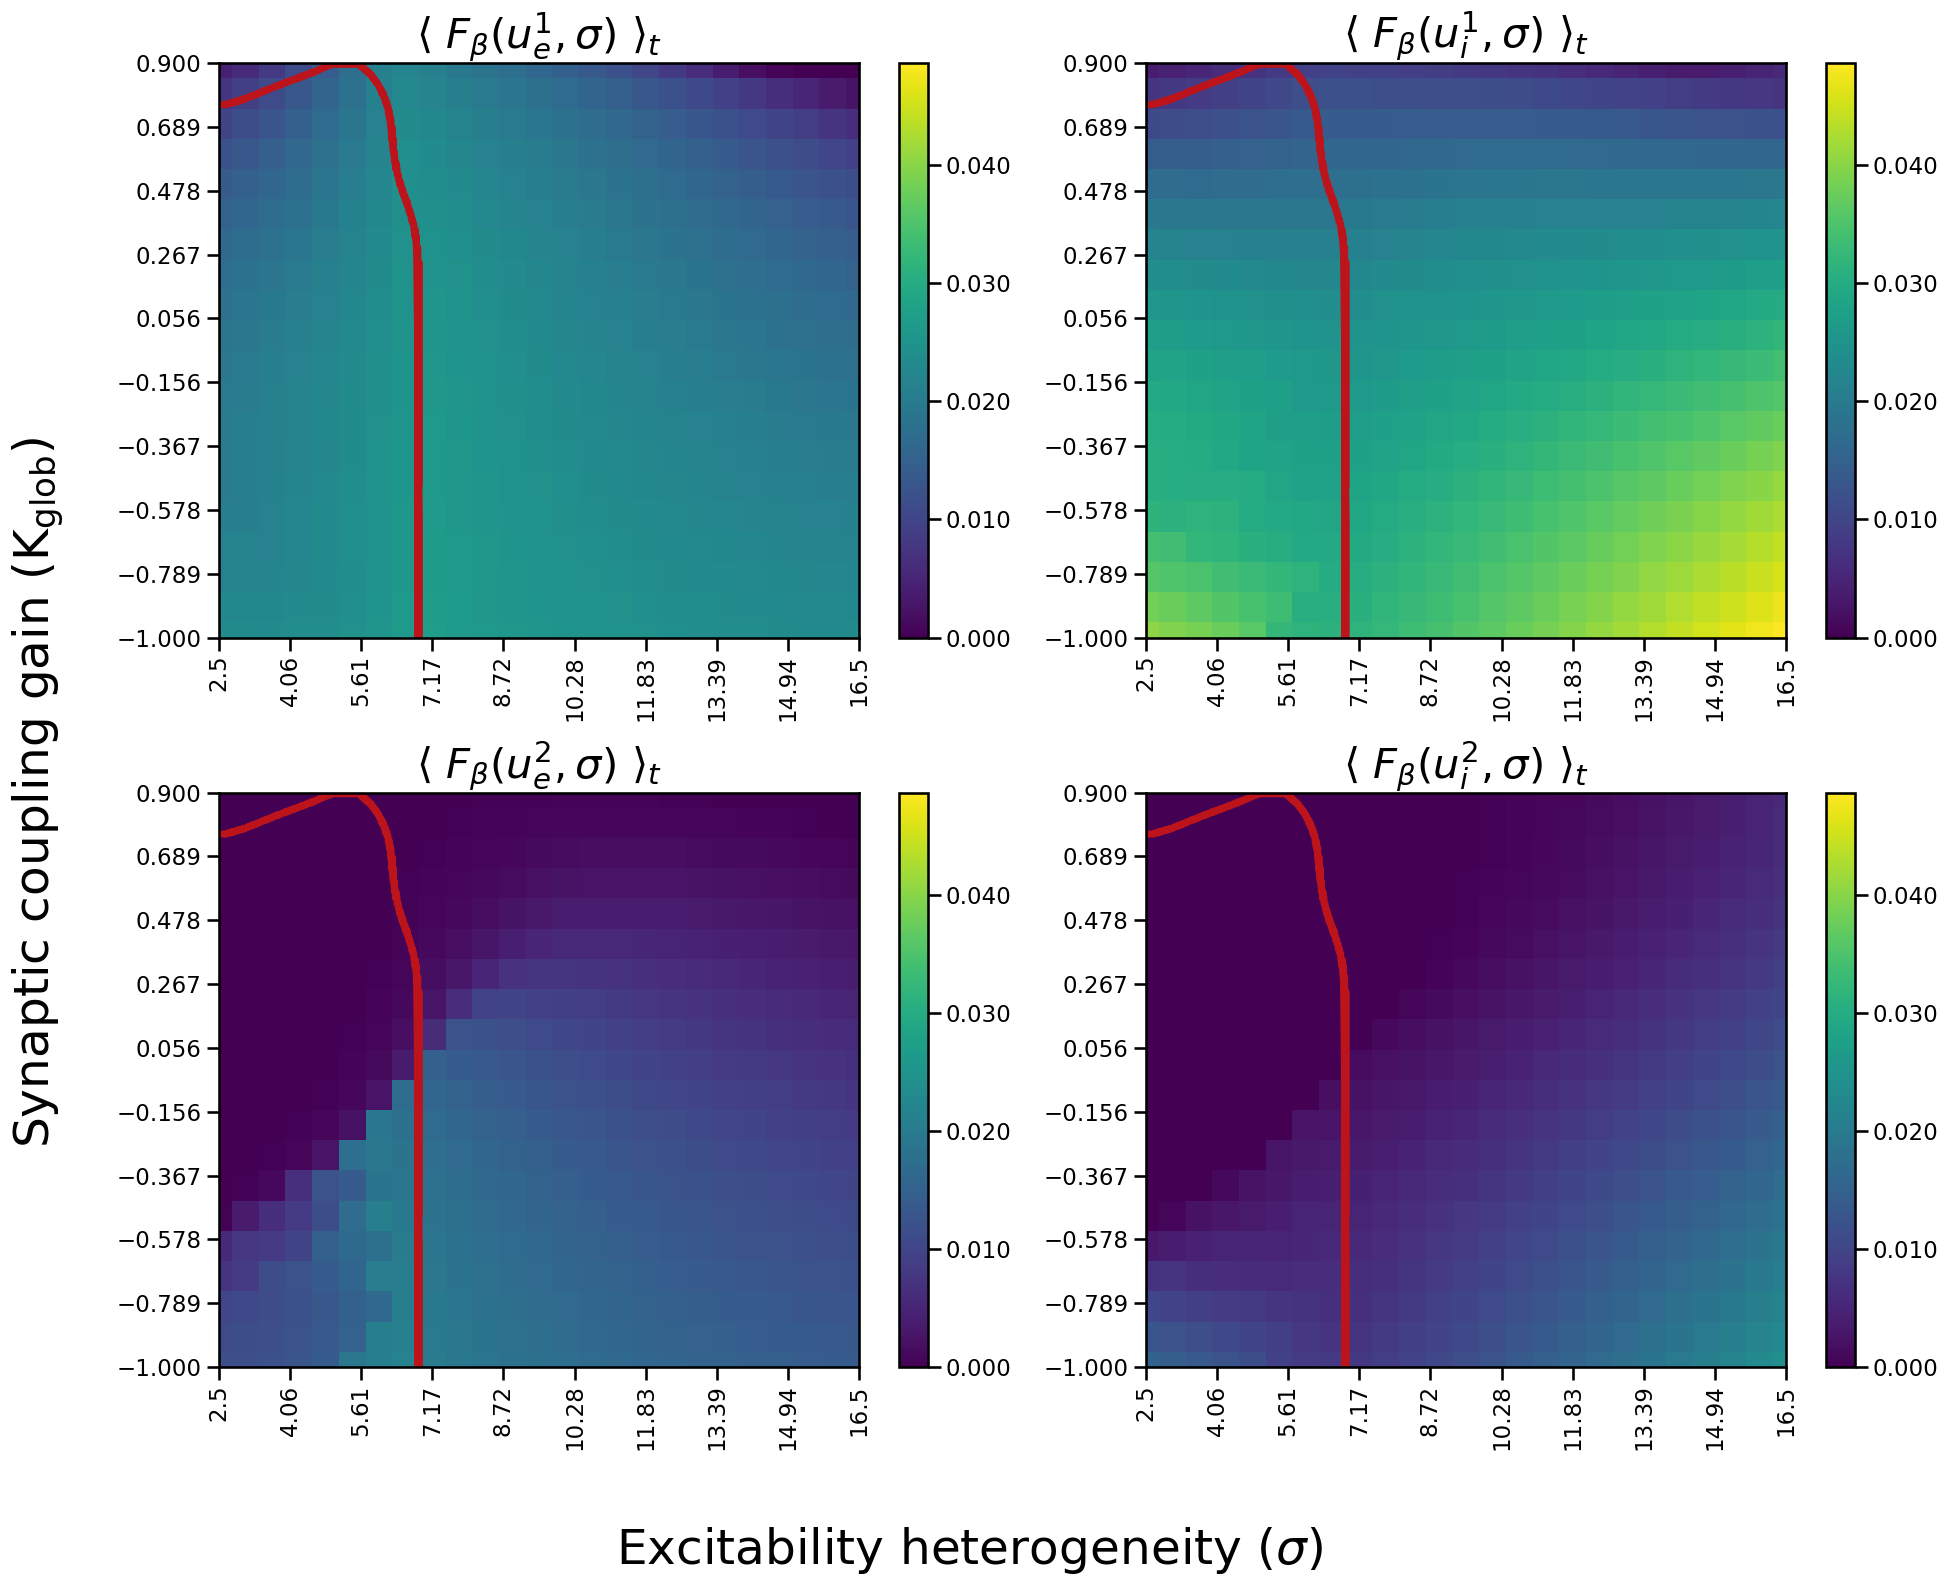

In [58]:
_I = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths = np.array(file_paths)[_Isort]

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.45, 0.8, len(_I))))
subtitles = [r"$\langle~ F_{\beta}(u_e^1, \sigma) ~\rangle_t$", r"$\langle~ F_{\beta}(u_i^1, \sigma)~\rangle_t$", 
             r"$\langle~ F_{\beta}(u_e^2, \sigma)~\rangle_t$", r"$\langle~ F_{\beta}(u_i^2, \sigma)~\rangle_t$"]


for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    color = next(colorIter)
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])

    ## Reading the Lyapunov exponent file corresponding to eah I value

    lyap_results_boundary = pickle.load(open(f"../system_01/results/lyapunov_numba/exp-2025-1-14/lyap_ie_{I:.3f}_dt_{params['dt']}ms.pkl", 'rb'))
    lyap_results_boundary = lyap_results_boundary['n1_mean'] if type(lyap_results_boundary) == dict else lyap_results_boundary

    orig_response = lyapunov_threshold(lyap_results_boundary, 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response=orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )

    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)


    ## Reading the F(u) value file
    lyap_results = pickle.load(open(path, 'rb'))
    lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results
    vMax = np.max(lyap_results); vMin = np.min(lyap_results)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20,16))
    nCol = 0; nRow = 0
    for i in range(4):
        heatmap = axes[nCol, nRow].pcolormesh(sVals, kVals, lyap_results[i, :, :], vmin=vMin, vmax=vMax)
        cbar = plt.colorbar(heatmap, format='%.3f')
        axes[nCol, nRow].plot(sig_edges, k_edges, linewidth=5, c = color, label = r"$\rm I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV")

        axes[nCol, nRow].set_xticks(np.round(np.linspace(sMin, max(sVals), 10), 2))
        axes[nCol, nRow].set_xticklabels(np.round(np.linspace(sMin, max(sVals), 10), 2), rotation = 90)
        axes[nCol, nRow].set_yticks(np.linspace(kMin, max(kVals), 10))
        axes[nCol, nRow].set_xlim(sMin, max(sVals)); axes[nCol, nRow].set_ylim(kMin, max(kVals))

        axes[nCol, nRow].set_title(subtitles[i], fontsize=30)

        nRow += 1
        if (i % 2) == 1:
            nRow = 0; nCol += 1
    
    fig.supxlabel(f"\n" + r"Excitability heterogeneity $(\sigma)$", fontsize=35); fig.supylabel(r"Synaptic coupling gain $(\rm K_{glob})$" + f"\n", fontsize=35)
    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, f"Average_FU_Heatmaps_{params.get('dt')*10:.3f}ms_ie_{I:.3f}mV.jpg"), dpi = 300, bbox_inches='tight')
    plt.show()

In [22]:
file_paths[-1]

'../system_01/results/Fu_numba/exp-2025-1-17/Fu_ie_15.625_D0_0.000_dt_0.005ms.pkl'

In [8]:
### Loading files to prepare the boundaries for system simulations with noise.

save_str = datetime.datetime(2025, 1, 16)
params['dt'] = 0.005
results_dict = os.path.join('../system_01/results/lyapunov_numba/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, f"*_dt_{params['dt']}ms.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 4


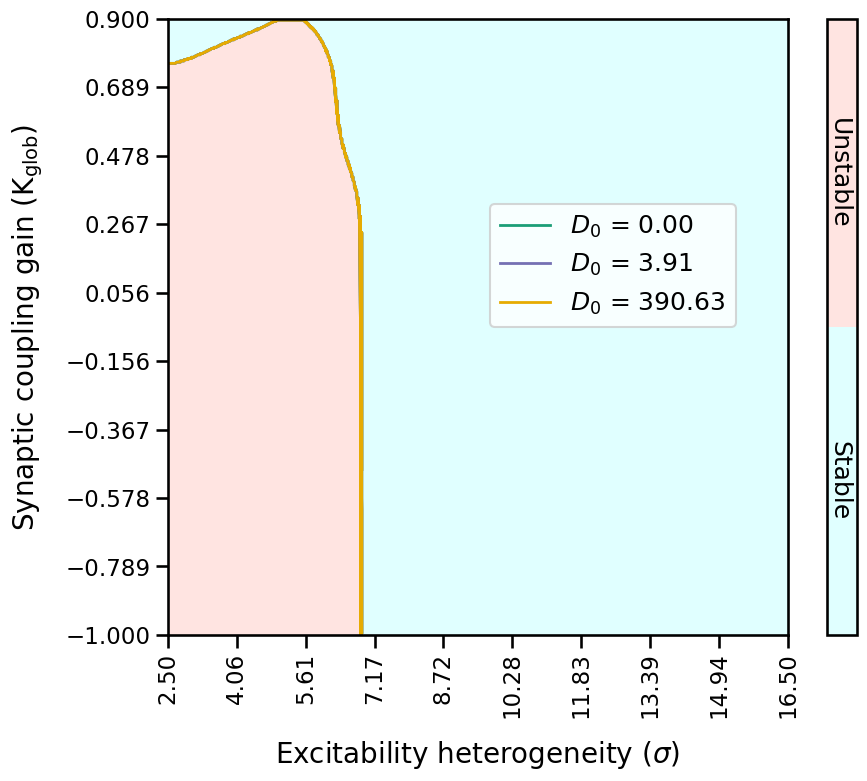

In [11]:
_D0 = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    D0 = float(basename.split('D0_')[-1].split('_dt_')[0])
    _D0.append(D0 / (params['gamma']**2))

_D0 = np.array(_D0)

_D0sort = np.argsort(_D0)
_D0 = _D0[_D0sort]
file_paths = np.array(file_paths)[_D0sort]

colors= plt.get_cmap('Dark2')
colorIter = iter(colors(np.linspace(0, 1, len(_D0))))

plt.figure(figsize=(10,8))
for nf, path in enumerate(file_paths[:-1]):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_D0_')[0].split('ie_')[-1])

    lyap_results = pickle.load(open(path, 'rb'))
    lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results
    

    orig_response = lyapunov_threshold(lyap_results, 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response = orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )
    
    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)

    if edge_boundary is None:
        continue

    plot_x = np.linspace(min(sig_edges), max(sig_edges), 1000)
    plot_y = edge_boundary(plot_x)

    color = next(colorIter)
    plt.plot(sig_edges, k_edges, linewidth = 2, label = r"$D_0$ = " + f"{_D0[nf]:.2f}", color=color)

    if _D0[nf] == _D0[0]:
        heatmap = plt.pcolormesh(sig_arr, k_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
        cbar = plt.colorbar(heatmap)

        cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0.4, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=18)
        cbar.ax.text(0.4, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=18)

plt.xlabel(r"Excitability heterogeneity $(\sigma)$", labelpad=15, fontsize=20); plt.ylabel(r"Synaptic coupling gain $(\rm K_{glob})$", labelpad=15, fontsize=20)
plt.xticks(np.linspace(sMin, max(sVals), 10), rotation = 90); plt.yticks(np.linspace(kMin, max(kVals), 10))
plt.xlim(sMin, max(sVals)); plt.ylim(kMin, max(kVals))
plt.legend(loc = 'center left', bbox_to_anchor=(0.5, 0.6), fontsize=18)
plt.savefig(os.path.join(figureroot, f"boundarydetection_noise_dt_{params['dt'] * 10}ms.png"), dpi = 300, bbox_inches='tight')

In [10]:
### Loading files to prepare the boundaries for system simulations without noise.

save_str = datetime.datetime(2025, 1, 14)
params['dt'] = 0.005
results_dict = os.path.join('../system_01/results/lyapunov_numba/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, f"*_dt_{params['dt']}ms.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 5


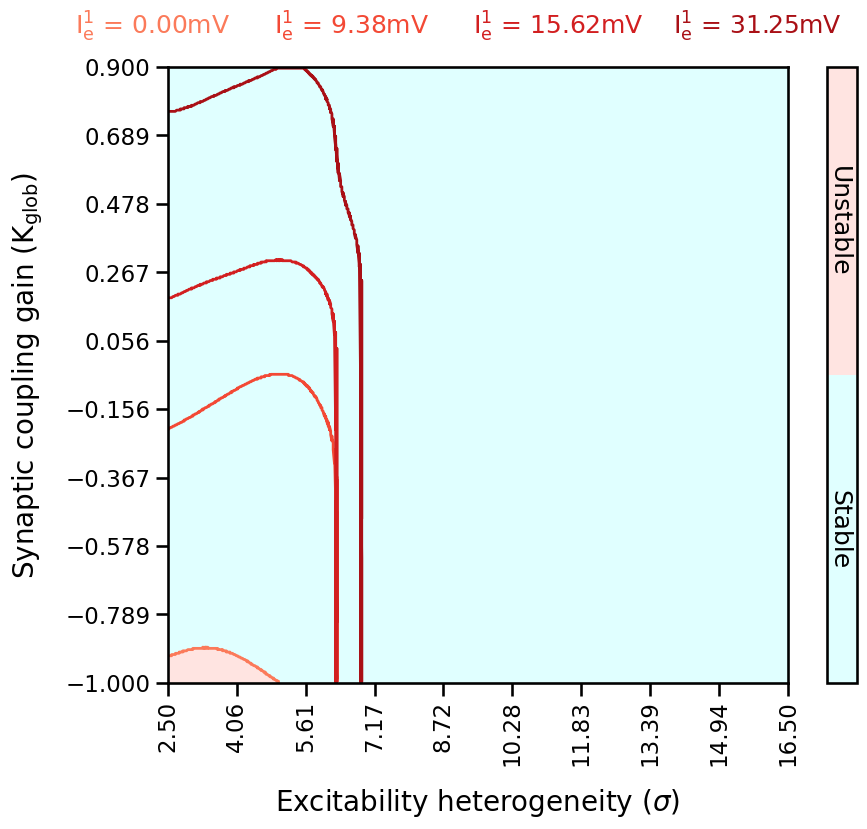

In [11]:
_I = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_ie_')[-1].split('_dt_')[0])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths = np.array(file_paths)[_Isort]

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.45, 1, len(_I))))

plt.figure(figsize=(10,8))
counter = 0
for nf, path in enumerate(file_paths):
    if nf == 3:
        continue
    basename = os.path.basename(path).split('.pkl')[0]
    color = next(colorIter)

    lyap_results = pickle.load(open(path, 'rb'))
    lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results

    orig_response = lyapunov_threshold(lyap_results, 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response=orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )
    
    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)

    if edge_boundary is None:
        continue

    plot_x = np.linspace(min(sig_edges), max(sig_edges), 1000)
    plot_y = edge_boundary(plot_x)

    plt.plot(sig_edges, k_edges, linewidth=2, c = color, label = r"$\rm I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV")
    
    plt.text(counter * 4.5 + 0.4, 1, r"$\rm I^1_e$ = " + f"{_I[nf] - params['i_e2']:.2f}mV", color=color, fontsize=18)
    counter += 1

    if nf == 0:
        heatmap = plt.pcolormesh(sig_arr, k_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
        cbar = plt.colorbar(heatmap)

        cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0.4, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=18)
        cbar.ax.text(0.4, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=18)

plt.xlabel(r"Excitability heterogeneity $(\sigma)$", labelpad=15, fontsize=20); plt.ylabel(r"Synaptic coupling gain $({\rm K_{glob}})$", labelpad=15, fontsize=20)
plt.xticks(np.linspace(sMin, max(sVals), 10), rotation = 90); plt.yticks(np.linspace(kMin, max(kVals), 10))
plt.xlim(sMin, max(sVals)); plt.ylim(kMin, max(kVals))
plt.savefig(os.path.join(figureroot, f"boundarydetection_modulation_{params.get('dt')*10:.3f}ms.png"), dpi = 300, bbox_inches='tight')
plt.show()